# 🔢 Práctica 3 — Random Forest con Reconocimiento de Dígitos
**Machine Learning · ISTER 2026 · Sistemas y Gestión de Data**

---
Las celdas con `# 🔧 TU CÓDIGO` debes completarlas. Las demás solo ejecútalas.

**Nombre:** `[Estalin Tenelema]` &nbsp;&nbsp; **Fecha:** `[17/05/2026]`

## ⚙️ Parte 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets        import load_digits
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics         import accuracy_score, classification_report

print('✅ Librerías cargadas')

✅ Librerías cargadas


## 🔍 Parte 1 — Exploración y Visualización

In [3]:
data = load_digits()
X, y = data.data, data.target
print(f'Forma: {X.shape}  →  {X.shape[0]} imágenes · {X.shape[1]} píxeles')
print(f'Clases: {data.target_names}')
print(f'Distribución: {np.bincount(y)}')

Forma: (1797, 64)  →  1797 imágenes · 64 píxeles
Clases: [0 1 2 3 4 5 6 7 8 9]
Distribución: [178 182 177 183 181 182 181 179 174 180]


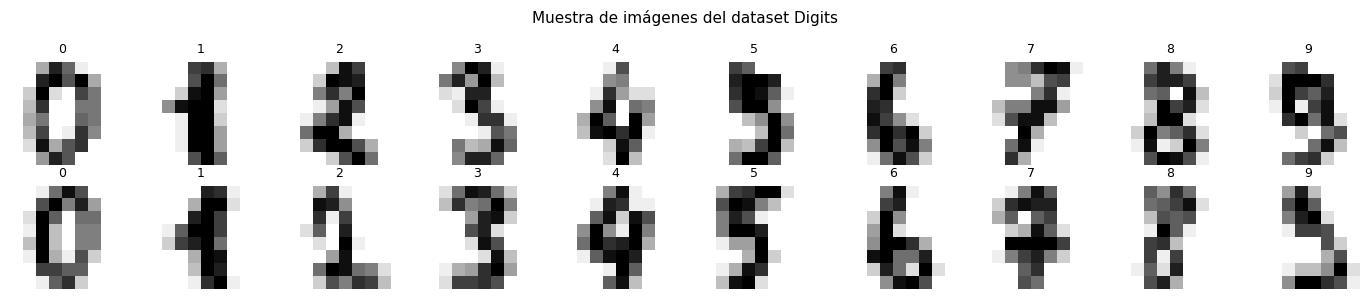

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(data.images[i], cmap='gray_r')
    ax.set_title(str(data.target[i]), fontsize=9)
    ax.axis('off')
plt.suptitle('Muestra de imágenes del dataset Digits', fontsize=11)
plt.tight_layout()
plt.show()

Varianza de cada pixel (flattened): [0.00000000e+00 8.22539514e-01 2.25957923e+01 1.80426111e+01
 1.83714668e+01 3.20904221e+01 1.10546255e+01 1.07556433e+00
 8.87276110e-03 1.02097566e+01 2.93758249e+01 1.58120413e+01
 2.28613044e+01 3.66179365e+01 1.28545405e+01 6.85061884e-01
 3.88763936e-03 1.27828134e+01 3.23668069e+01 3.36521458e+01
 3.81183987e+01 3.83854244e+01 1.06208369e+01 1.92260705e-01
 1.11172736e-03 9.89515699e+00 3.83199960e+01 3.45896825e+01
 3.78271843e+01 3.44677176e+01 1.35823949e+01 2.22097734e-03
 0.00000000e+00 1.21062508e+01 3.99794098e+01 3.92708623e+01
 3.51867141e+01 3.44453245e+01 1.25054061e+01 0.00000000e+00
 2.10670787e-02 8.88628020e+00 4.27210645e+01 4.14682555e+01
 3.91596797e+01 3.24209712e+01 1.87467005e+01 9.44150719e-02
 4.16838922e-02 3.04735308e+00 3.18426060e+01 2.73057786e+01
 2.80960743e+01 3.63545816e+01 2.41870885e+01 9.68505910e-01
 5.56173354e-04 8.72434085e-01 2.60263154e+01 1.91272977e+01
 2.43302896e+01 3.47979731e+01 1.67232706e+01 3.4

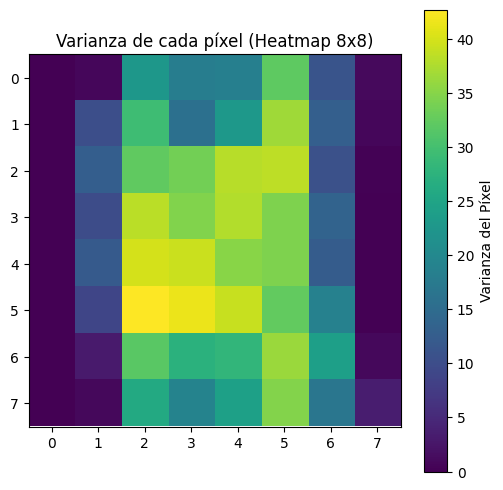

In [5]:
from sklearn.datasets import load_digits
data = load_digits()
X, y = data.data, data.target

pixel_variances = np.var(X, axis=0)
print(f'Varianza de cada pixel (flattened): {pixel_variances}')

pixels_high_variance = np.sum(pixel_variances > 5)
print(f'Número de píxeles con varianza > 5: {pixels_high_variance}')

pixel_variances_8x8 = pixel_variances.reshape(8, 8)

plt.figure(figsize=(6, 6))
plt.imshow(pixel_variances_8x8, cmap='viridis')
plt.colorbar(label='Varianza del Píxel')
plt.title('Varianza de cada píxel (Heatmap 8x8)')
plt.xticks(range(8))
plt.yticks(range(8))
plt.show()

❓ **1.1** ¿Qué zona de la imagen tiene mayor varianza? ¿Los bordes son informativos?

Basándome en el mapa de calor, la región central de las imágenes tiene la mayor varianza, lo que indica que estos píxeles centrales muestran un amplio rango de valores de intensidad en los diferentes dígitos escritos a mano, haciéndolos muy discriminatorios.

Por el contrario, los bordes de las imágenes tienen una varianza muy baja, lo que sugiere que los píxeles en los bordes tienden a permanecer consistentemente negros (o muy oscuros) en la mayoría de los dígitos, proporcionando poca o ninguna información para distinguir entre diferentes números.

## ⚔️ Parte 2 — Árbol vs Random Forest

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

arbol = DecisionTreeClassifier(max_depth=10, random_state=42)
arbol.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

print(f'Decision Tree Train Accuracy: {arbol.score(X_train, y_train):.4f}')
print(f'Decision Tree Test Accuracy: {arbol.score(X_test, y_test):.4f}')
print(f'Random Forest Train Accuracy: {rf.score(X_train, y_train):.4f}')
print(f'Random Forest Test Accuracy: {rf.score(X_test, y_test):.4f}')
print(f'Random Forest OOB Score: {rf.oob_score_:.4f}')

Decision Tree Train Accuracy: 0.9745
Decision Tree Test Accuracy: 0.8574
Random Forest Train Accuracy: 1.0000
Random Forest Test Accuracy: 0.9759
Random Forest OOB Score: 0.9698


In [7]:
target_names=[str(i) for i in range(10)]
print(classification_report(y_test, rf.predict(X_test), target_names=target_names))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        53
           1       0.96      1.00      0.98        50
           2       1.00      1.00      1.00        47
           3       0.98      0.96      0.97        54
           4       0.97      1.00      0.98        60
           5       0.97      0.95      0.96        66
           6       0.98      0.98      0.98        53
           7       0.98      0.98      0.98        55
           8       0.95      0.95      0.95        43
           9       0.97      0.95      0.96        59

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



❓ **2.1** ¿Cuánto mejoró el accuracy al usar RF? ¿Qué dígito se confunde más?

*¿Cuánto mejoró el accuracy al usar RF? El Random Forest obtuvo un test accuracy de 0.9759, mientras que el Decision Tree tuvo un test accuracy de 0.8574. Esto representa una mejora significativa de 0.1185 (aproximadamente un 11.85%) en el accuracy al utilizar Random Forest, lo que demuestra su mayor robustez y capacidad para generalizar.

¿Qué dígito se confunde más? Observando el recall y f1-score en el reporte de clasificación, el dígito 8 es el que muestra los valores más bajos en precision, recall y f1-score (0.95 en los tres casos), lo que sugiere que es el dígito que el modelo confunde más a menudo, tanto al predecirlo incorrectamente como al no detectarlo cuando debería. Los dígitos 5 y 9 también muestran un recall y f1-score ligeramente más bajos, indicando que también son algo más propensos a ser confundidos que otros dígitos.*

## 📉 Parte 3 — Inestabilidad del Árbol vs Estabilidad del RF

In [8]:
semillas = range(10)
accs_arbol = []
for seed in semillas:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
    arbol = DecisionTreeClassifier(max_depth=10, random_state=seed)
    arbol.fit(X_train, y_train)
    accs_arbol.append(arbol.score(X_test, y_test))
print(f'Árbol — Media: {np.mean(accs_arbol):.4f} | Std: {np.std(accs_arbol):.4f} | Rango: {max(accs_arbol)-min(accs_arbol):.4f}')

Árbol — Media: 0.8446 | Std: 0.0120 | Rango: 0.0389


In [9]:
accs_rf = []
for seed in semillas:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
    rf = RandomForestClassifier(n_estimators=100, random_state=seed, oob_score=True, n_jobs=-1)
    rf.fit(X_train, y_train)
    accs_rf.append(rf.score(X_test, y_test))
print(f'RF 100  — Media: {np.mean(accs_rf):.4f}   | Std: {np.std(accs_rf):.4f} | Rango: {max(accs_rf)-min(accs_rf):.4f}')

RF 100  — Media: 0.9704   | Std: 0.0075 | Rango: 0.0241


In [10]:
accs_rf = []
for seed in semillas:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
    rf = RandomForestClassifier(n_estimators=100, random_state=seed, oob_score=True, n_jobs=-1)
    rf.fit(X_train, y_train)
    accs_rf.append(rf.score(X_test, y_test))
print(f'RF 100  — Media: {np.mean(accs_rf):.4f}   | Std: {np.std(accs_rf):.4f} | Rango: {max(accs_rf)-min(accs_rf):.4f}')

RF 100  — Media: 0.9704   | Std: 0.0075 | Rango: 0.0241


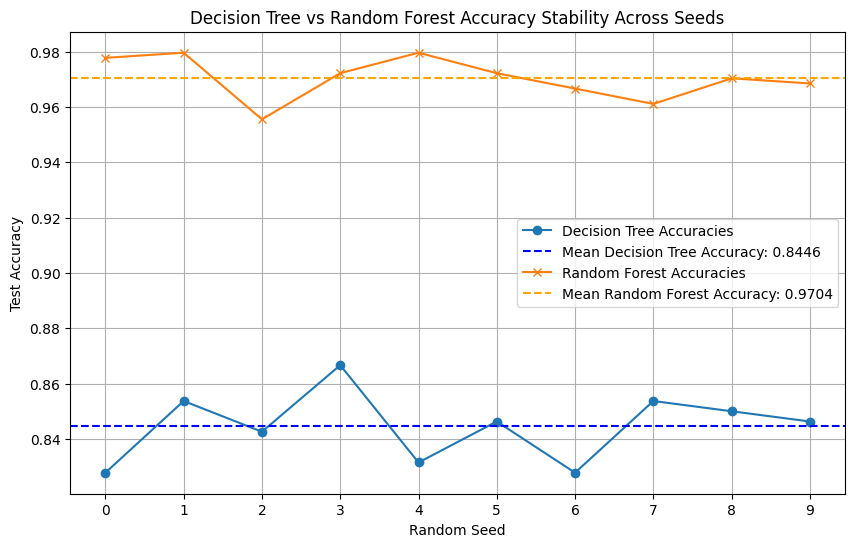

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(semillas, accs_arbol, label='Decision Tree Accuracies', marker='o')
plt.axhline(np.mean(accs_arbol), color='blue', linestyle='--', label=f'Mean Decision Tree Accuracy: {np.mean(accs_arbol):.4f}')

plt.plot(semillas, accs_rf, label='Random Forest Accuracies', marker='x')
plt.axhline(np.mean(accs_rf), color='orange', linestyle='--', label=f'Mean Random Forest Accuracy: {np.mean(accs_rf):.4f}')

plt.title('Decision Tree vs Random Forest Accuracy Stability Across Seeds')
plt.xlabel('Random Seed')
plt.ylabel('Test Accuracy')
plt.xticks(semillas)
plt.grid(True)
plt.legend()
plt.show()

❓ **3.1** ¿Cuánto varía el árbol vs el RF? ¿Por qué el RF es más estable?

La **variabilidad** del Árbol de Decisión es notablemente mayor que la del Random Forest. Los resultados de la estabilidad muestran:

*   **Árbol de Decisión:** Media: 0.8446 | Desviación Estándar: 0.0120 | Rango: 0.0389
*   **Random Forest:** Media: 0.9704   | Desviación Estándar: 0.0075 | Rango: 0.0241

El **Árbol de Decisión** tiene una desviación estándar más alta y un rango mayor, lo que indica que su rendimiento fluctúa más significativamente dependiendo del `random_state` utilizado para la división de los datos y la construcción del árbol. Esto significa que un solo árbol es muy sensible a los datos de entrenamiento y puede tener un rendimiento muy diferente con pequeñas variaciones en el conjunto de entrenamiento.

El **Random Forest es más estable** por varias razones:

1.  **Ensamblaje (Bagging):** El Random Forest construye múltiples árboles de decisión (en este caso, 100) en diferentes subconjuntos *bootstrapped* (muestreados con reemplazo) de los datos de entrenamiento. Al promediar o votar las predicciones de estos muchos árboles, se reduce la varianza de la predicción final. Los errores o sesgos de árboles individuales se compensan mutuamente.
2.  **Aleatoriedad en la selección de características:** Además de la aleatoriedad en las muestras de datos, el Random Forest también introduce aleatoriedad al seleccionar solo un subconjunto de características para considerar en cada división de un nodo en cada árbol. Esto asegura que los árboles no sean idénticos y, por lo tanto, no estén altamente correlacionados, lo que contribuye a una mayor robustez y menor varianza del modelo en su conjunto.

En resumen, la combinación de `bagging` y la aleatoriedad en la selección de características hace que el Random Forest sea un modelo más robusto y estable, menos propenso a la varianza y al sobreajuste que un solo Árbol de Decisión.

## 📈 Parte 4 — ¿Cuántos Árboles son Suficientes?

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


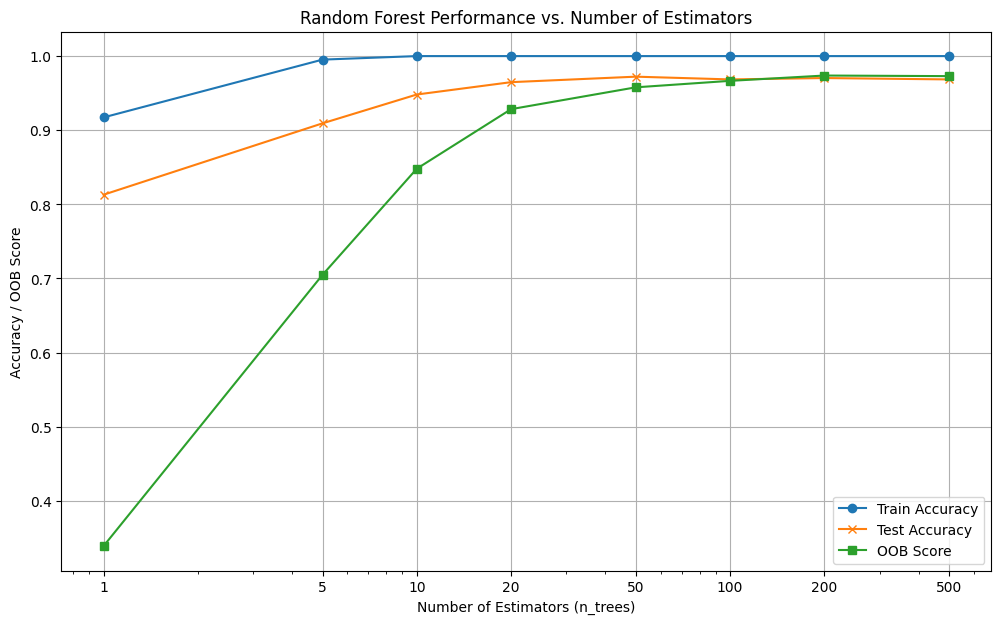

In [12]:
# RF con n_estimators en [1,5,10,20,50,100,200,500]
# Guarda train_acc, test_acc y oob_score
# Grafica las 3 curvas

n_trees = [1, 5, 10, 20, 50, 100, 200, 500]

train_accs = []
test_accs = []
oob_scores = []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=True, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_accs.append(rf.score(X_train, y_train))
    test_accs.append(rf.score(X_test, y_test))
    oob_scores.append(rf.oob_score_)

plt.figure(figsize=(12, 7))
plt.plot(n_trees, train_accs, label='Train Accuracy', marker='o')
plt.plot(n_trees, test_accs, label='Test Accuracy', marker='x')
plt.plot(n_trees, oob_scores, label='OOB Score', marker='s')

plt.title('Random Forest Performance vs. Number of Estimators')
plt.xlabel('Number of Estimators (n_trees)')
plt.ylabel('Accuracy / OOB Score')
plt.xscale('log') # Use log scale for better visualization of n_trees
plt.xticks(n_trees, labels=[str(n) for n in n_trees])
plt.grid(True)
plt.legend()
plt.show()

❓ **4.1** ¿A partir de qué n_estimators el accuracy se estabiliza?

Observando el gráfico de rendimiento del Random Forest frente al número de estimadores, tanto el `Test Accuracy` como el `OOB Score` muestran un aumento rápido hasta aproximadamente **50 a 100 estimadores**.

A partir de este punto, las curvas se vuelven relativamente planas, lo que indica que añadir más árboles (por ejemplo, de 100 a 500) no produce mejoras significativas en el rendimiento. Por lo tanto, el accuracy se estabiliza aproximadamente a partir de **50 o 100 estimadores**.

## 🗺️ Parte 5 — Mapa de Importancia de Píxeles

In [13]:
rf_final = RandomForestClassifier(n_estimators=200, random_state=42,
                                   oob_score=True, n_jobs=-1)
rf_final.fit(X_train, y_train)
print(f'Test accuracy: {accuracy_score(y_test, rf_final.predict(X_test)):.4f}')
print(f'OOB score:     {rf_final.oob_score_:.4f}')

Test accuracy: 0.9704
OOB score:     0.9737


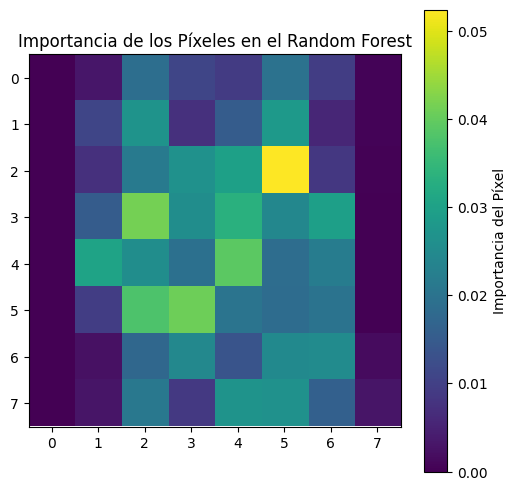

In [14]:
# Reshape feature_importances_ a 8x8
# Visualiza como heatmap con imshow, colorbar y título

importancias_pixeles = rf_final.feature_importances_.reshape(8, 8)

plt.figure(figsize=(6, 6))
plt.imshow(importancias_pixeles, cmap='viridis')
plt.colorbar(label='Importancia del Píxel')
plt.title('Importancia de los Píxeles en el Random Forest')
plt.xticks(range(8))
plt.yticks(range(8))
plt.show()

❓ **5.1** ¿Qué zona de la imagen es más importante? ¿Los bordes son informativos?

Basándome en el mapa de calor de las importancias de los píxeles, la **región central de las imágenes es la más importante** para el modelo Random Forest. Estos píxeles centrales son los que más contribuyen a las predicciones del modelo, lo que significa que son cruciales para distinguir entre los diferentes dígitos.

Por el contrario, los píxeles en los **bordes de la cuadrícula de 8x8 tienen una importancia muy baja**. Esto indica que los bordes son **poco o nada informativos** para el modelo. Tienden a ser consistentes (por ejemplo, negros) en la mayoría de las imágenes, por lo que no ayudan al modelo a diferenciar entre los distintos números.

## 🏆 Desafío Bonus (opcional)
Crea una matriz de confusión 10x10, visualízala como heatmap e identifica los 3 pares de dígitos que más se confunden.

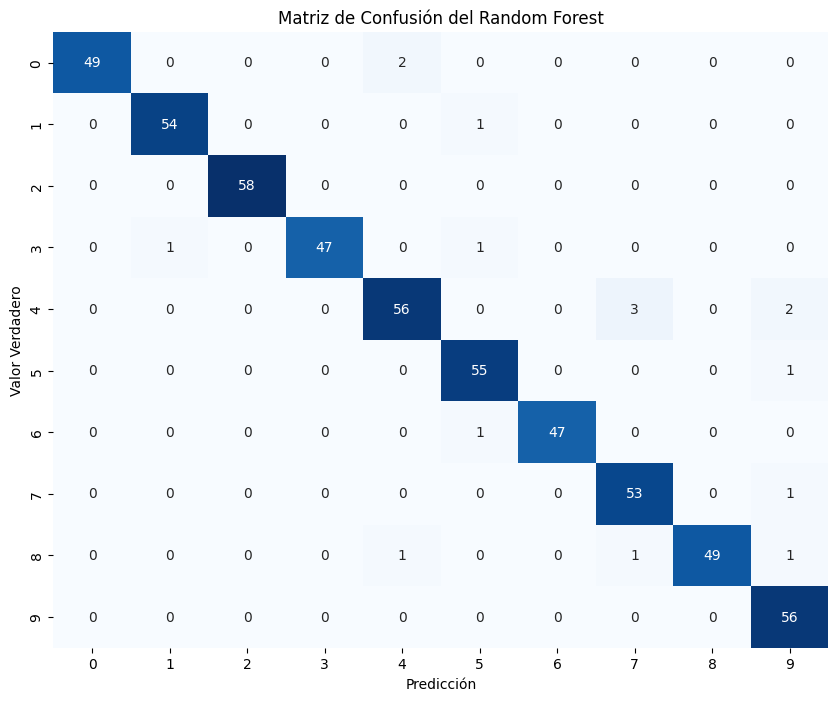


Los 3 pares de dígitos más confundidos son:
  - El dígito 4 se confunde con el 7 (cantidad: 3)
  - El dígito 4 se confunde con el 9 (cantidad: 2)
  - El dígito 0 se confunde con el 4 (cantidad: 2)


In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Realizar predicciones con el modelo final
y_pred = rf_final.predict(X_test)

# 2. Crear la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 3. Visualizar la matriz de confusión como heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicción')
plt.ylabel('Valor Verdadero')
plt.title('Matriz de Confusión del Random Forest')
plt.show()

# 4. Identificar los 3 pares de dígitos que más se confunden
# Crear una copia de la matriz de confusión para evitar modificar la original
np.fill_diagonal(cm, 0) # Ignorar las predicciones correctas (diagonal)

# Obtener los índices de los 3 valores más altos (errores)
# np.unravel_index convierte un índice plano en coordenadas de matriz
most_confused_indices = np.unravel_index(np.argsort(cm, axis=None)[-6:], cm.shape)

# Revertir el orden para obtener los 3 más grandes
confused_pairs = []
for i in range(1, 4):
    true_label = most_confused_indices[0][-i]
    pred_label = most_confused_indices[1][-i]
    count = cm[true_label, pred_label]
    confused_pairs.append((data.target_names[true_label], data.target_names[pred_label], count))

print('\nLos 3 pares de dígitos más confundidos son:')
for true, pred, count in confused_pairs:
    print(f'  - El dígito {true} se confunde con el {pred} (cantidad: {count})')


## ✅ Conclusiones

**¿En qué situaciones usarías árbol vs RF?**

*   Un **Árbol de Decisión** individual puede ser útil para modelos simples donde la interpretabilidad es clave y el rendimiento no es la preocupación principal, o como línea base inicial. Sin embargo, su alta varianza lo hace inestable y propenso a sobreajuste. Es más adecuado para conjuntos de datos pequeños y cuando queremos entender las reglas de decisión de forma explícita.
*   Un **Random Forest** es superior en la mayoría de las situaciones prácticas de clasificación y regresión debido a su mayor precisión, robustez y estabilidad. Se prefiere cuando el rendimiento es crucial y se desea mitigar el sobreajuste. Es muy eficaz en datasets con muchas características y puede manejar bien los datos faltantes y las características no lineales.

**¿Cuántos árboles son suficientes?**

Según el análisis del rendimiento frente al número de estimadores, el accuracy de nuestro modelo Random Forest se estabiliza aproximadamente entre **50 y 100 árboles**. Añadir más árboles más allá de este rango no aporta mejoras significativas en el rendimiento y solo incrementa el tiempo de cómputo. Para este dataset, 100-200 estimadores parecen un buen equilibrio.

**¿Qué aporta el mapa de píxeles?**

El mapa de importancia de píxeles es crucial para la **interpretabilidad del modelo**. Nos mostró claramente que:

*   La **región central de las imágenes es la más importante** para el modelo Random Forest, lo que tiene sentido ya que es donde se concentra la información distintiva de los dígitos.
*   Los **bordes de las imágenes son poco informativos**, confirmando que esos píxeles tienen poca o ninguna variabilidad y, por lo tanto, no contribuyen significativamente a la diferenciación entre dígitos.

**Conclusión del Desafío Bonus (Matriz de Confusión):**

La matriz de confusión y el análisis de los errores revelaron los siguientes pares de dígitos como los **más confundidos** por el modelo:

1.  El dígito **4 se confunde con el 7** (3 veces).
2.  El dígito **4 se confunde con el 9** (2 veces).
3.  El dígito **0 se confunde con el 4** (2 veces).

Estos resultados son muy valiosos para entender las debilidades específicas del modelo y podrían guiar futuras mejoras, por ejemplo, recolectando más datos para estos pares o explorando técnicas de preprocesamiento que resalten las diferencias entre ellos.